# Evaluación 1

**Integrante 1:** José Ignacio Peña Ovalle

**Integrante 2:** Gabriel Esteban Jerez Salas

**Integrante 3:** Javier Ignacio Villena Novoa

**Correo Electrónico integrante 1:** jose.pena1801@alumnos.ubiobio.cl

**Correo Electrónico integrante 2:** gabriel.jerez2201@alumnos.ubiobio.cl

**Correo Electrónico integrante 3:** javier.villena2101@alumnos.ubiobio.cl

**Fecha de Creación:** Abril de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook contiene el desarrollo de la evaluación 1 de la asignatura Inteligencia Artificial de la carrera de Ingeniería Civil en Informática de la Universidad del Bio Bio, sede Concepción.


---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

# Instalar librerias

In [15]:
!pip install pandas numpy matplotlib scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Verificar Versiones librerias

In [16]:
import pandas as pd
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, FunctionTransformer

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)

pandas: 3.0.2
numpy: 2.1.0
matplotlib: 3.9.2


# Carga de datos

In [17]:
!wget -P ../data  https://raw.githubusercontent.com/JaznaLaProfe/datos/master/preparation_data/dataset_churn_dirty.csv

"wget" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [18]:
df = pd.read_csv(filepath_or_buffer="../data/dataset_churn_dirty.csv",)

print(df.shape)
display(df.head())
display(df.columns)

(21000, 16)


,customer_id,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,gender,subscription_type,region,payment_method,is_active,preferred_device,churn
0,1,39.0,NaN,76,42,30.297419,0,70965.479058,47431.757551,Other,Enterprise,West,NaN,Yes,Desktop,1
1,2,69.0,1.352838e+06,46,27,50.666766,3,62653.316701,26134.009301,Other,Basic,South,Debit Card,No,Mobile,1
2,3,NaN,9.127957e+05,83,23,53.086839,1,46918.415548,15390.195033,NaN,Enterprise,West,NaN,No,Mobile,0
3,4,79.0,7.955275e+05,45,23,55.197774,1,22665.546094,41163.281718,Female,Premium,South,Debit Card,No,Tablet,1
4,5,52.0,4.425135e+05,98,29,67.781999,3,58510.036769,14704.401069,Male,Basic,West,Credit Card,Yes,Mobile,0


Index(['customer_id', 'age', 'monthly_income', 'tenure_months',
       'num_logins_last_month', 'avg_session_time', 'support_tickets',
       'account_balance', 'last_payment_amount', 'gender', 'subscription_type',
       'region', 'payment_method', 'is_active', 'preferred_device', 'churn'],
      dtype='str')

En esta sección se cargó el dataset ***dataset_churn_dirty.csv*** en un DataFrame de pandas mediante ***pd.read_csv()***. Luego, con ***df.shape*** se verificó que el archivo contiene 21000 filas y 16 columnas, con ***df.head()*** se visualizaron los primeros registros y con ***df.columns*** se identificaron las variables del dataset.

# Revisión de nulos

In [19]:
nulos = df.isnull().sum()
porcentaje_nulos = (df.isnull().mean() * 100).round(2)
union_total_nulos = (df.isnull().any(axis=1).sum()).round(2)
tabla_nulos = pd.DataFrame({
    "Variable": df.columns,
    "Valores nulos": nulos.values,
    "Porcentaje (%)": porcentaje_nulos.values
})

tabla_nulos = tabla_nulos[tabla_nulos["Valores nulos"] > 0]
tabla_nulos = tabla_nulos.sort_values(by="Valores nulos", ascending=False)

print("Total de valores nulos:", (df.isnull().any(axis=1).sum()).round(2))
display(tabla_nulos)
print("Union de nulos en total: ", (union_total_nulos/(len(df)+1)*100).round(2),"%")

Total de valores nulos: 3875


,Variable,Valores nulos,Porcentaje (%)
9,gender,1053,5.01
12,payment_method,1047,4.99
2,monthly_income,1038,4.94
1,age,1036,4.93


Union de nulos en total:  18.45 %


En esta sección se revisaron los valores nulos del dataset. Con el comando **df.isnull().sum()** se calculó la cantidad de datos faltantes por cada variable, mientras que con **(df.isnull().mean() * 100)** se obtuvo su porcentaje respecto del total de registros. Luego, mediante **pd.DataFrame()**, estos resultados se organizaron en una tabla para presentarlos de forma más clara y facilitar su análisis.

# Revisión de atípicos

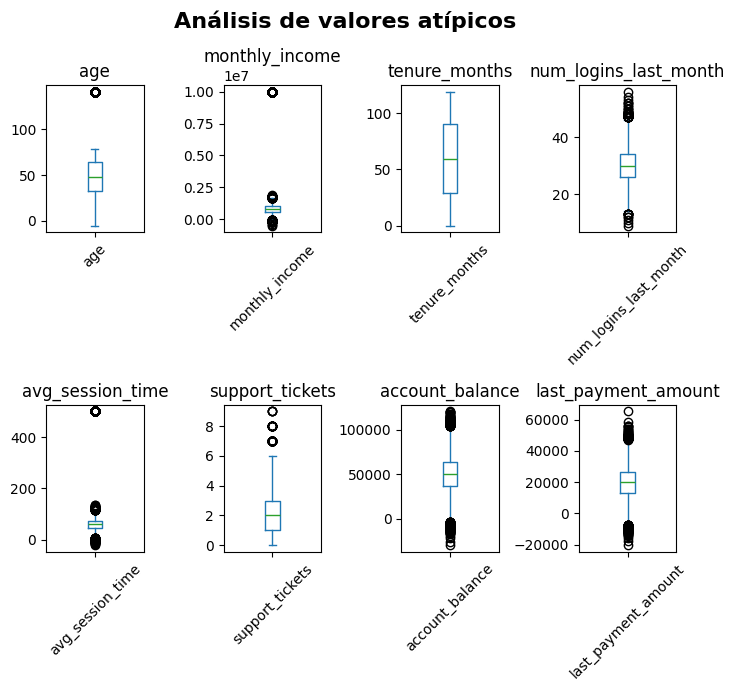

In [20]:
revision_atipicos = [
    'age',
    'monthly_income',
    'tenure_months',
    'num_logins_last_month',
    'avg_session_time',
    'support_tickets',
    'account_balance',
    'last_payment_amount'
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(revision_atipicos):
    df[col].plot(kind='box', figsize=(7, 7), ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', labelrotation=45)

plt.suptitle("Análisis de valores atípicos", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

En esta sección se revisaron los valores atípicos de las variables numéricas mediante gráficos de caja (**boxplot**). Esta visualización permite observar la distribución general de los datos, la mediana, el rango central y los posibles valores extremos.

En cada gráfico, la caja representa el 50% central de los datos, la línea interior corresponde a la mediana y las líneas que se extienden desde la caja muestran el rango normal de variación de la variable. Los puntos que aparecen fuera de estos límites se consideran posibles valores atípicos, ya que se alejan del comportamiento general de la variable.

A partir del análisis visual, se observó presencia de valores atípicos en varias variables del dataset, especialmente en **monthly_income**, **avg_session_time**, **account_balance** y **last_payment_amount**. Esto sugiere la existencia de observaciones extremas que deberán ser revisadas en la etapa de limpieza, ya que podrían corresponder tanto a casos reales poco frecuentes como a errores o inconsistencias en los datos.

# Revisión de inconsistencias

In [21]:
# Valores esperados según metadata
valid_gender = ["Male", "Female", "Other"]
valid_subscription = ["Basic", "Premium", "Enterprise"]
valid_region = ["North", "South", "East", "West"]
valid_payment = ["Credit Card", "Debit Card", "PayPal", "Transfer"]
valid_active = ["Yes", "No"]
valid_device = ["Mobile", "Desktop", "Tablet"]
valid_churn = [0, 1]

# Revisión de inconsistencias
inconsistencias = {
    "age_fuera_de_rango_o_decimal": df[
        (df["age"] < 18) | (df["age"] > 100) | (df["age"] % 1 != 0)
    ]["age"].count(),

    "tenure_months_negativo_o_decimal": df[
        (df["tenure_months"] < 0) | (df["tenure_months"] % 1 != 0)
    ]["tenure_months"].count(),

    "num_logins_last_month_negativo_o_decimal": df[
        (df["num_logins_last_month"] < 0) | (df["num_logins_last_month"] % 1 != 0)
    ]["num_logins_last_month"].count(),

    "support_tickets_negativo_o_decimal": df[
        (df["support_tickets"] < 0) | (df["support_tickets"] % 1 != 0)
    ]["support_tickets"].count(),

    "monthly_income_negativo": df[
        df["monthly_income"] < 0
    ]["monthly_income"].count(),

    "avg_session_time_negativo": df[
        df["avg_session_time"] < 0
    ]["avg_session_time"].count(),

    "last_payment_amount_negativo": df[
        df["last_payment_amount"] < 0
    ]["last_payment_amount"].count(),

    "gender_invalido": df[
        ~df["gender"].isin(valid_gender) & df["gender"].notna()
    ]["gender"].count(),

    "subscription_type_invalido": df[
        ~df["subscription_type"].isin(valid_subscription) & df["subscription_type"].notna()
    ]["subscription_type"].count(),

    "region_invalida": df[
        ~df["region"].isin(valid_region) & df["region"].notna()
    ]["region"].count(),

    "payment_method_invalido": df[
        ~df["payment_method"].isin(valid_payment) & df["payment_method"].notna()
    ]["payment_method"].count(),

    "is_active_invalido": df[
        ~df["is_active"].isin(valid_active) & df["is_active"].notna()
    ]["is_active"].count(),

    "preferred_device_invalido": df[
        ~df["preferred_device"].isin(valid_device) & df["preferred_device"].notna()
    ]["preferred_device"].count(),

    "churn_invalido": df[
        ~df["churn"].isin(valid_churn)
    ]["churn"].count()
}

total_inconsistencias = sum(inconsistencias.values())
print("Total de inconsistencias detectadas:", total_inconsistencias)

tabla_inconsistencias = pd.DataFrame(
    inconsistencias.items(),
    columns=["Regla revisada", "Cantidad de inconsistencias"]
)

display(tabla_inconsistencias)
print("Porcentaje de inconsistencias: ",(sum(inconsistencias.values())/(len(df)+1) * 100).round(2),"%")

Total de inconsistencias detectadas: 1267


,Regla revisada,Cantidad de inconsistencias
0,age_fuera_de_rango_o_decimal,422
1,tenure_months_negativo_o_decimal,0
2,num_logins_last_month_negativo_o_decimal,0
3,support_tickets_negativo_o_decimal,0
4,monthly_income_negativo,294
5,avg_session_time_negativo,30
6,last_payment_amount_negativo,521
7,gender_invalido,0
8,subscription_type_invalido,0
9,region_invalida,0


Porcentaje de inconsistencias:  6.03 %


En esta sección se revisaron inconsistencias en variables numéricas y categóricas a partir de límites y reglas definidas según la naturaleza de cada dato y la metadata del dataset. Para **age** se consideró válido un rango entre 12 y 100 años, además de exigir valores enteros, tomando como referencia un criterio razonable para usuarios potenciales en el contexto chileno. En **tenure_months**, **num_logins_last_month** y **support_tickets** se esperaba que los datos fueran enteros y no negativos, por tratarse de conteos o cantidades discretas. En **monthly_income**, **avg_session_time** y **last_payment_amount** se aceptaron valores decimales, pero no negativos, ya que representan montos o medidas continuas.

En las variables categóricas se verificó que los valores coincidieran con los definidos en la metadata, como por ejemplo **gender** con *Male*, *Female* y *Other*, subscription_type con *Basic*, *Premium* y *Enterprise*, **region** con *North*, *South*, *East* y *West*, **payment_method** con *Credit Card*, *Debit Card*, *PayPal* y *Transfer*, **is_active** con *Yes* y *No*, **preferred_device** con *Mobile*, *Desktop* y *Tablet*, y **churn** con *0* y *1*. Cualquier valor fuera de estos límites o categorías fue considerado inconsistente.

# Revisión de duplicados

In [22]:
# Revisión de duplicados exactos
duplicados_totales = df.duplicated().sum()
print("Cantidad de registros duplicados exactos:", duplicados_totales)

duplicados_exactos = df[df.duplicated(keep=False)]
display(duplicados_exactos)

# Revisión de duplicados por identificador.
duplicados_customer = df.duplicated(subset=["customer_id"]).sum()
print("Cantidad de customer_id duplicados:", duplicados_customer)

duplicados_id = df[df.duplicated(subset=["customer_id"], keep=False)].sort_values(by="customer_id")
duplicados_id

Cantidad de registros duplicados exactos: 1000


,customer_id,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,gender,subscription_type,region,payment_method,is_active,preferred_device,churn
29,30,49.0,8.560272e+05,75,24,24.155548,1,36786.360402,24526.064563,Other,Premium,East,PayPal,Yes,Desktop,1
53,54,38.0,-1.000000e+05,15,28,80.815791,3,45750.504885,26898.056970,Male,Premium,East,Credit Card,Yes,Mobile,0
81,82,74.0,3.940678e+05,12,38,81.451588,2,73386.737914,15850.188316,Female,Enterprise,East,Transfer,No,Mobile,1
86,87,55.0,1.260388e+06,6,39,30.920359,2,33442.844103,16640.721219,Female,Basic,North,Credit Card,Yes,Mobile,1
101,102,44.0,1.101761e+06,63,34,54.542293,1,46290.508693,21640.596524,Male,Enterprise,North,PayPal,No,Tablet,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20995,17722,59.0,9.212134e+05,6,32,55.690940,4,107772.068497,17055.825833,Other,Premium,West,Credit Card,No,Desktop,0
20996,3461,23.0,6.824455e+05,63,36,64.531197,1,71619.219699,8880.655722,Female,Premium,North,Credit Card,Yes,Desktop,1
20997,3543,68.0,6.372404e+05,18,35,53.606069,1,38335.532706,28256.446769,Male,Enterprise,West,PayPal,No,Tablet,1
20998,18023,24.0,4.356965e+05,25,41,72.408040,0,57249.809484,10264.357562,Other,Basic,East,Credit Card,No,Mobile,0


Cantidad de customer_id duplicados: 1000


,customer_id,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,gender,subscription_type,region,payment_method,is_active,preferred_device,churn
29,30,49.0,8.560272e+05,75,24,24.155548,1,36786.360402,24526.064563,Other,Premium,East,PayPal,Yes,Desktop,1
20808,30,49.0,8.560272e+05,75,24,24.155548,1,36786.360402,24526.064563,Other,Premium,East,PayPal,Yes,Desktop,1
20676,54,38.0,-1.000000e+05,15,28,80.815791,3,45750.504885,26898.056970,Male,Premium,East,Credit Card,Yes,Mobile,0
53,54,38.0,-1.000000e+05,15,28,80.815791,3,45750.504885,26898.056970,Male,Premium,East,Credit Card,Yes,Mobile,0
81,82,74.0,3.940678e+05,12,38,81.451588,2,73386.737914,15850.188316,Female,Enterprise,East,Transfer,No,Mobile,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20660,19974,33.0,1.128085e+06,111,25,87.790691,1,84751.539493,16273.962321,Male,Premium,North,Transfer,Yes,Mobile,0
20686,19977,66.0,5.620763e+05,108,43,61.314927,3,51434.870846,25963.712853,Other,Basic,North,PayPal,No,Mobile,0
19976,19977,66.0,5.620763e+05,108,43,61.314927,3,51434.870846,25963.712853,Other,Basic,North,PayPal,No,Mobile,0
19989,19990,53.0,7.261838e+05,93,29,91.552765,5,70170.793757,21619.638950,Other,Basic,West,PayPal,No,Mobile,0


En esta sección se revisó la existencia de registros duplicados en el dataset. Primero se analizaron duplicados exactos, es decir, filas completamente repetidas considerando todas las variables. Luego, de forma complementaria, se revisó la existencia de duplicados en ***customer_id***, ya que corresponde al identificador del cliente. Esta revisión es importante porque los duplicados pueden afectar la calidad del análisis y sesgar el posterior modelamiento.

# Limpieza y transformación

In [23]:
# Clase para tratar valores atípicos
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, limits=(0.05, 0.05)):
        self.limits = limits

    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            self.columns_ = X.columns
        else:
            self.columns_ = np.arange(X.shape[1])
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.columns_).copy()

        for col in self.columns_:
            lower = X[col].quantile(self.limits[0])
            upper = X[col].quantile(1 - self.limits[1])
            X[col] = np.clip(X[col], lower, upper)

        return X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array(self.columns_)
        return np.array(input_features)

# Copia del dataset original
df_clean = df.copy()

# Eliminar duplicados exactos
df_clean = df_clean.drop_duplicates()

# Corregir inconsistencias
valid_gender = ["Male", "Female", "Other"]
valid_subscription = ["Basic", "Premium", "Enterprise"]
valid_region = ["North", "South", "East", "West"]
valid_payment = ["Credit Card", "Debit Card", "PayPal", "Transfer"]
valid_active = ["Yes", "No"]
valid_device = ["Mobile", "Desktop", "Tablet"]
valid_churn = [0, 1]

df_clean.loc[(df_clean["age"] < 12) | (df_clean["age"] > 100) | (df_clean["age"] % 1 != 0), "age"] = np.nan
df_clean.loc[(df_clean["tenure_months"] < 0) | (df_clean["tenure_months"] % 1 != 0), "tenure_months"] = np.nan
df_clean.loc[(df_clean["num_logins_last_month"] < 0) | (df_clean["num_logins_last_month"] % 1 != 0), "num_logins_last_month"] = np.nan
df_clean.loc[(df_clean["support_tickets"] < 0) | (df_clean["support_tickets"] % 1 != 0), "support_tickets"] = np.nan

df_clean.loc[df_clean["monthly_income"] < 0, "monthly_income"] = np.nan
df_clean.loc[df_clean["avg_session_time"] < 0, "avg_session_time"] = np.nan
df_clean.loc[df_clean["last_payment_amount"] < 0, "last_payment_amount"] = np.nan

df_clean.loc[~df_clean["gender"].isin(valid_gender), "gender"] = np.nan
df_clean.loc[~df_clean["subscription_type"].isin(valid_subscription), "subscription_type"] = np.nan
df_clean.loc[~df_clean["region"].isin(valid_region), "region"] = np.nan
df_clean.loc[~df_clean["payment_method"].isin(valid_payment), "payment_method"] = np.nan
df_clean.loc[~df_clean["is_active"].isin(valid_active), "is_active"] = np.nan
df_clean.loc[~df_clean["preferred_device"].isin(valid_device), "preferred_device"] = np.nan
df_clean.loc[~df_clean["churn"].isin(valid_churn), "churn"] = np.nan

# Feature engineering
df_clean["engagement_score"] = df_clean["num_logins_last_month"] * df_clean["avg_session_time"]

df_clean["payment_to_income_ratio"] = np.where(
    df_clean["monthly_income"] > 0,
    df_clean["last_payment_amount"] / df_clean["monthly_income"],
    np.nan
)

# Eliminar filas sin churn válido
df_clean = df_clean.dropna(subset=["churn"])

# Separar variables predictoras y objetivo
X = df_clean.drop(columns=["customer_id", "churn"])
y = df_clean["churn"].astype(int).reset_index(drop=True)

# Definir variables numéricas y categóricas
numeric_features = [
    "age",
    "monthly_income",
    "tenure_months",
    "num_logins_last_month",
    "avg_session_time",
    "support_tickets",
    "account_balance",
    "last_payment_amount",
    "engagement_score",
    "payment_to_income_ratio"
]

categorical_features = [
    "gender",
    "subscription_type",
    "region",
    "payment_method",
    "is_active",
    "preferred_device"
]

# Pipelines de transformación
pipeline_numerico = Pipeline(steps=[
    ("winsorizer", Winsorizer()),
    ("imputer", SimpleImputer(strategy="median"))
])

pipeline_categorico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(categories=[
            ["Male","Female","Other"],
            ["Basic", "Premium", "Enterprise"],
            ["North", "South", "East", "West"],
            ["Credit Card", "Debit Card", "PayPal", "Transfer"],
            ["Yes", "No"],
            ["Mobile", "Desktop", "Tablet"],

        ]))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", pipeline_numerico, numeric_features),
    ("cat", pipeline_categorico, categorical_features)
])

# Aplicar transformación
X_transformado = preprocessor.fit_transform(X)

print(X_transformado.shape)

(20000, 16)


En este bloque se realizó la preparación inicial del dataset. Primero se creó una copia de los datos originales para trabajar de forma segura sin alterar la fuente. Luego se eliminaron registros duplicados exactos y se corrigieron inconsistencias identificadas previamente, reemplazando por valores nulos aquellos datos que no cumplían las reglas definidas para variables numéricas y categóricas.

Posteriormente, se aplicó feature engineering mediante la creación de dos nuevas variables: **engagement_score**, asociada al nivel de uso de la plataforma, y **payment_to_income_ratio**, relacionada con la proporción entre el último pago y el ingreso mensual del cliente. Finalmente, se separaron las variables predictoras y la variable objetivo churn, y se definieron pipelines de transformación para variables numéricas y categóricas, incorporando tratamiento de atípicos, imputación de valores faltantes y codificación de categorías.

# Guarda set de datos limpio y transformado

In [26]:
nombres_categoricos = preprocessor.named_transformers_["cat"] \
    .named_steps["ordinal"] \
    .get_feature_names_out(categorical_features)

columnas_finales = numeric_features + list(nombres_categoricos)

data_clean_final = pd.DataFrame(
    X_transformado.toarray() if hasattr(X_transformado, "toarray") else X_transformado,
    columns=columnas_finales
)

data_clean_final["churn"] = y
data_clean_final.columns = data_clean_final.columns.str.replace("num__", "")
data_clean_final.columns = data_clean_final.columns.str.replace("cat__", "")
print("Dimensiones del dataset limpio y transformado:", data_clean_final.shape)
display(data_clean_final.head())

data_clean_final.to_csv("../data/dataset_churn_prepared.csv", index_label="customer_id")
print("Dataset guardado correctamente como 'dataset_churn_prepared.csv'")

Dimensiones del dataset limpio y transformado: (20000, 17)


,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,engagement_score,payment_to_income_ratio,gender,subscription_type,region,payment_method,is_active,preferred_device,churn
0,39.0,8.051280e+05,76.0,39.0,30.297419,0.0,70965.479058,36591.288387,1272.491586,0.025341,2.0,2.0,3.0,2.0,0.0,1.0,1
1,69.0,1.327572e+06,46.0,27.0,50.666766,3.0,62653.316701,26134.009301,1368.002673,0.019318,2.0,0.0,1.0,1.0,1.0,0.0,1
2,48.0,9.127957e+05,83.0,23.0,53.086839,1.0,46918.415548,15390.195033,1220.997297,0.016861,2.0,2.0,3.0,2.0,1.0,0.0,0
3,76.0,7.955275e+05,45.0,23.0,55.197774,1.0,22665.546094,36591.288387,1269.548794,0.051743,1.0,1.0,1.0,1.0,1.0,2.0,1
4,52.0,4.425135e+05,98.0,29.0,67.781999,3.0,58510.036769,14704.401069,1965.677962,0.033229,0.0,0.0,3.0,0.0,0.0,0.0,0


Dataset guardado correctamente como 'dataset_churn_prepared.csv'


En este bloque se reconstruyó el dataset final a partir de las variables ya transformadas. Para ello, se generaron los nombres de las nuevas columnas resultantes del proceso de codificación de variables categóricas y se integraron con las variables numéricas procesadas. Luego se reincorporó la variable objetivo churn, obteniendo así un set de datos limpio y transformado, listo para la fase posterior de modelamiento predictivo. Finalmente, el dataset fue guardado en formato .csv para su uso futuro.